# GameTheory-6c : Jeux Répétés et Théorème Folk (Folk Theorem)

**Navigation** : [<< 6-EvolutionTrust](GameTheory-06-EvolutionTrust.ipynb) | [Index](README.md) | [7-ExtensiveForm >>](GameTheory-07-ExtensiveForm.ipynb)

Ce notebook est le compagnon **formel** de [GameTheory-06-EvolutionTrust](GameTheory-06-EvolutionTrust.ipynb). Là, GT-6 étudiait de façon **empirique** comment la coopération émerge dans des tournois itérés (Axelrod, dynamique du réplicateur). Ici, nous établissons le résultat **théorique** qui l'explique : pourquoi et à quelles conditions la coopération est un équilibre crédible dans un jeu répété infini.


## Objectifs d'apprentissage

À l'issue de ce notebook, vous saurez :
1. Distinguer un jeu répété **fini** (où la coopération s'effondre par induction vers l'arrière) d'un jeu répété **infini** (où elle peut être soutenable).
2. Formaliser le **facteur d'escompte** $\delta$ et écrire la valeur actualisée d'un flux de gains comme série géométrique.
3. Établir la **condition de crédibilité** du grim trigger : $\delta \ge (T-R)/(T-P)$.
4. Énoncer et illustrer le **Folk Theorem** : tout paiement faisable et individuellement rationnel est soutenable comme équilibre parfait en sous-jeux (SPNE) pour des joueurs assez patients.

### Prérequis
- [GameTheory-06-EvolutionTrust](GameTheory-06-EvolutionTrust.ipynb) (Dilemme du Prisonnier, tit-for-tat, intuition de la coopération itérée).
- Algèbre linéaire et séries géométriques de base.

### Durée estimée : 45 minutes


## 1. Le jeu étape (Dilemme du Prisonnier)

On reprend le Dilemme du Prisonnier de GT-6 (convention Axelrod) :

| | Coopérer (C) | Défecter (D) |
|---|---|---|
| **Coopérer (C)** | R=3, R=3 | S=0, T=5 |
| **Défecter (D)** | T=5, S=0 | P=1, P=1 |

avec **T** (tentation) > **R** (récompense) > **P** (punition) > **S** (dupe), et la condition $2R > T+S$. L'unique équilibre de Nash du jeu étape est **(D, D)** (paiement P=1), alors que la coopération mutuelle (R=3) est strictement Pareto-supérieure : c'est le dilemme.


In [1]:
import numpy as np

# Matrice des gains du Dilemme du Prisonnier (lignes = joueur 1, colonnes = joueur 2)
# Ordre des actions : Cooperer (0), Defecter (1)
T, R, P, S = 5.0, 3.0, 1.0, 0.0   # Axelrod convention
A1 = np.array([[R, S],   # joueur 1 coopere
               [T, P]])  # joueur 1 defecte
A2 = np.array([[R, T],   # joueur 2 coopere
               [S, P]])  # joueur 2 defecte

print('Gain joueur 1 (lignes=J1, colonnes=J2):')
print(A1)
print()
print('Verif des inegalites du DP : T>R>P>S :', T > R > P > S)
print('Verif 2R > T+S :', 2*R > T+S, '(2R=%g, T+S=%g)' % (2*R, T+S))
print('Equilibre de Nash du jeu etape : (D,D) -> paiement P =', P)
print('Pareto-optimum cooperatif : (C,C) -> paiement R =', R)


Gain joueur 1 (lignes=J1, colonnes=J2):
[[3. 0.]
 [5. 1.]]

Verif des inegalites du DP : T>R>P>S : True
Verif 2R > T+S : True (2R=6, T+S=5)
Equilibre de Nash du jeu etape : (D,D) -> paiement P = 1.0
Pareto-optimum cooperatif : (C,C) -> paiement R = 3.0


## 2. Horizon fini : l'effondrement inévitable

Considérons une répétition **finie** de N tours. On résout par **induction vers l'arrière** : au dernier tour N, il n'y a pas d'avenir à menacer, donc chaque joueur défecte (c'est l'équilibre du jeu étape). Sachant cela au tour N-1, aucune menace future n'est crédible, donc on défecte aussi. Et ainsi de suite jusqu'au tour 1 : **(D, D) à chaque tour**.

> **Théorème (effondrement de l'horizon fini)** : dans tout jeu répété un nombre **connu** et **fini** de fois, le seul SPNE est la défection perpétuelle, pourvu que le jeu étape ait un unique équilibre de Nash.

La coopération exige donc un horizon **infini** (ou une probabilité positive de continuer à chaque tour).


In [2]:
# Illustration : dans un jeu fini, la defection perpetuelle est l'unique SPNE.
# Valeurs actualisees (delta=1, pas d'escompte) sur N tours :

N = 10
payoff_defect_always = P * N          # (D,D) chaque tour
payoff_cooperate_if_possible = R * N  # (C,C) chaque tour, irrealiste en horizon fini
print('Horizon fini N =', N, 'tours (delta=1)')
print('  Paiement SPNE (D,D)xN   = %.1f' % payoff_defect_always)
print('  Paiement coop. fictif   = %.1f (NON credible : effondre par induction)' % payoff_cooperate_if_possible)
print()
print('Conclusion : en horizon fini, le SPNE = defaction, paiement total = P*N = %.1f' % payoff_defect_always)
print('La cooperation (R=%.1f > P=%.1f) exige un horizon INFINI.' % (R, P))


Horizon fini N = 10 tours (delta=1)
  Paiement SPNE (D,D)xN   = 10.0
  Paiement coop. fictif   = 30.0 (NON credible : effondre par induction)

Conclusion : en horizon fini, le SPNE = defaction, paiement total = P*N = 10.0
La cooperation (R=3.0 > P=1.0) exige un horizon INFINI.


## 3. Horizon infini et facteur d'escompte

On suppose maintenant que le jeu se répète **infiniment**, avec un facteur d'escompte $\delta \in [0,1[$ ($1$ unité de gain demain vaut $\delta$ aujourd'hui ; $\delta$ proche de 1 = joueur patient). Le paiement total d'un joueur est la **somme actualisée** :

$$ V = u_0 + \delta u_1 + \delta^2 u_2 + \cdots = \sum_{t=0}^{\infty} \delta^t u_t $$

Pour un flux **constant** de gains $g$ chaque tour, la série géométrique se simplifie en :

$$ V(g) = \frac{g}{1 - \delta} $$

($\delta < 1$ garantit la convergence). C'est cette forme fermée qui rend l'analyse des jeux répétés infinis tractable.


In [3]:
# Verif numerique de la serie geometrique g/(1-delta)
def flux_geom(g, delta, terms=2000):
    """Somme actualisee d'un flux constant g sur 'terms' tours."""
    return sum((delta**t) * g for t in range(terms))

for delta in [0.3, 0.5, 0.7, 0.9, 0.99]:
    closed = R / (1 - delta)
    approx = flux_geom(R, delta)
    print('delta=%-5s : formule g/(1-d)=%10.4f | somme tronquee=%10.4f' % (delta, closed, approx))
print()
print('Les deux colonnes coincident : la serie converge vers g/(1-delta).')


delta=0.3   : formule g/(1-d)=    4.2857 | somme tronquee=    4.2857
delta=0.5   : formule g/(1-d)=    6.0000 | somme tronquee=    6.0000
delta=0.7   : formule g/(1-d)=   10.0000 | somme tronquee=   10.0000
delta=0.9   : formule g/(1-d)=   30.0000 | somme tronquee=   30.0000
delta=0.99  : formule g/(1-d)=  300.0000 | somme tronquee=  300.0000

Les deux colonnes coincident : la serie converge vers g/(1-delta).


## 4. Le grim trigger et sa condition de crédibilité

La stratégie du **grim trigger** (le vengeur implacable) est : *coopérer tant que l'autre a coopéré, mais si l'autre défecte une seule fois, défecter pour toujours*. C'est une menace maximale, **irréversible**.

Comparons, du point de vue du joueur 1 (admettant que le joueur 2 joue grim trigger) :

- **Coopérer toujours** : paiement $R$ chaque tour $\Rightarrow V_C = R/(1-\delta)$.
- **Défecter une fois** (gain $T$ au tour de la défection), puis le joueur 2 applique grim trigger $\Rightarrow$ punition $P$ chaque tour ensuite $\Rightarrow V_D = T + \delta P/(1-\delta)$.

La coopération est **soutenable** (incitation à ne pas dévier) ssi $V_C \ge V_D$ :

$$ \frac{R}{1-\delta} \ge T + \frac{\delta P}{1-\delta} \quad\Longleftrightarrow\quad \delta \ge \frac{T - R}{T - P} $$

**Application numérique** (cellule suivante) : pour le DP canonique $T=5, R=3, P=1$, le seuil vaut $\delta^* = (5-3)/(5-1) = 0{,}5$. En dessous (ex. $\delta=0{,}3$ : $V_C \approx 4{,}29 < V_D \approx 5{,}43$), la tentation l'emporte et la défection est rationnelle ; au-dessus (ex. $\delta=0{,}7$ : $V_C = 10 > V_D \approx 7{,}33$), la coopération est crédible. Exactement au seuil $\delta^*=0{,}5$, les joueurs sont indifférents ($V_C = V_D = 6$).


In [4]:
# Derivation numerique de la condition de credibilite
# V_C = R/(1-d), V_D = T + d*P/(1-d). Cooperation soutenable si V_C >= V_D.

def VC(delta): return R / (1 - delta)
def VD(delta): return T + delta * P / (1 - delta)

# Seuil exact (T-R)/(T-P)
delta_star = (T - R) / (T - P)
print('Stage game : T=%g R=%g P=%g S=%g' % (T, R, P, S))
print('Seuil de credibilite delta* = (T-R)/(T-P) = (%g-%g)/(%g-%g) = %.4f' % (T, R, T, P, delta_star))
print()
print('%-8s %-12s %-12s %s' % ('delta', 'V_C(coop)', 'V_D(deviat)', 'Coop. soutenable?'))
for delta in [0.30, 0.40, 0.50, 0.60, 0.70]:
    vc, vd = VC(delta), VD(delta)
    flag = 'OUI' if vc >= vd else 'NON'
    print('%-8.2f %-12.4f %-12.4f %s' % (delta, vc, vd, flag))
print()
print('Verification au seuil delta*=0.5 : V_C=%.4f, V_D=%.4f (indifference)' % (VC(delta_star), VD(delta_star)))


Stage game : T=5 R=3 P=1 S=0
Seuil de credibilite delta* = (T-R)/(T-P) = (5-3)/(5-1) = 0.5000

delta    V_C(coop)    V_D(deviat)  Coop. soutenable?
0.30     4.2857       5.4286       NON
0.40     5.0000       5.6667       NON
0.50     6.0000       6.0000       OUI
0.60     7.5000       6.5000       OUI
0.70     10.0000      7.3333       OUI

Verification au seuil delta*=0.5 : V_C=6.0000, V_D=6.0000 (indifference)


## 5. Tit-for-tat vs grim trigger

Le **tit-for-tat** (TFT, œil pour œil : coopérer au tour 1, puis copier le coup précédent de l'adversaire) est plus **clément** que le grim trigger : il pardonne après une seule coopération revenue. Mais sa clémence a un coût : la condition de crédibilité est plus stricte.

- TFT vs TFT : coopération perpétuelle, paiement $R/(1-\delta)$.
- Déviation vs TFT (défecter, puis TFT punit un tour puis pardonne) : paiement $T + \delta S + \delta^2 R/(1-\delta)$ (on gagne $T$ en déviant, $S$ au tour de contre-punition, puis retour à $R$).

La coopération sous TFT est soutenable ssi $R/(1-\delta) \ge T + \delta S + \delta^2 R/(1-\delta)$, soit un seuil plus élevé car la punition est plus légère.


In [5]:
# Comparaison des seuils : grim trigger (punition dure) vs tit-for-tat (punition legere)
def VC2(delta): return R / (1 - delta)
def VD_grim(delta): return T + delta * P / (1 - delta)
def VD_tft(delta):  return T + delta * S + (delta**2) * R / (1 - delta)  # TFT punit 1 tour puis pardonne

# Seuil grim trigger (exact) et TFT (numerique)
deltas = np.linspace(0.01, 0.99, 10000)
delta_grim = (T - R) / (T - P)
tft_ok = VC2(deltas) >= VD_tft(deltas)
delta_tft = deltas[np.argmax(tft_ok)] if tft_ok.any() else float('nan')

print('Seuil grim trigger : delta* = %.4f  (punition P a jamais)' % delta_grim)
print('Seuil tit-for-tat  : delta* = %.4f  (punition legere, pardonne)' % delta_tft)
print()
print('Conclusion : grim trigger soutient la cooperation pour delta >= %.3f' % delta_grim)
print('             tit-for-tat exige  delta >= %.3f (PLUS patient requis)' % delta_tft)
print('Punition plus dure => cooperation plus facile a soutenir (folk theorem intuition).')


Seuil grim trigger : delta* = 0.5000  (punition P a jamais)
Seuil tit-for-tat  : delta* = 0.6668  (punition legere, pardonne)

Conclusion : grim trigger soutient la cooperation pour delta >= 0.500
             tit-for-tat exige  delta >= 0.667 (PLUS patient requis)
Punition plus dure => cooperation plus facile a soutenir (folk theorem intuition).


## 6. Le Folk Theorem

Le grim trigger montre qu'**une** paire de paiements coopératifs $(R,R)$ est soutenable. Le **Folk Theorem** généralise considérablement ce résultat.

> **Folk Theorem (version jeux répétés infinis, joueurs patients)** : Soit $v = (v_1, v_2)$ un vecteur de paiements **faisable** (combinaison convexe des paiements du jeu étape) et **individuellement rationnel** ($v_i \ge \underline{v}_i$, le paiement de minimax du joueur $i$). Alors il existe $\underline{\delta} < 1$ tel que pour tout $\delta \ge \underline{\delta}$, $v$ est soutenable comme paiement d'un SPNE du jeu répété infini.

**Interprétation** : pour des joueurs assez patients ($\delta \to 1$), **presque tout** résultat est crédible comme équilibre. C'est à la fois la puissance (la coopération est robuste) et la faiblesse (le concept d'équilibre perd son pouvoir prédictif : tout peut être un équilibre).

Le **paiement de minimax** $\underline{v}_i$ est le pire que les autres puissent infliger au joueur $i$ (dans le DP symétrique, c'est $P=1$).


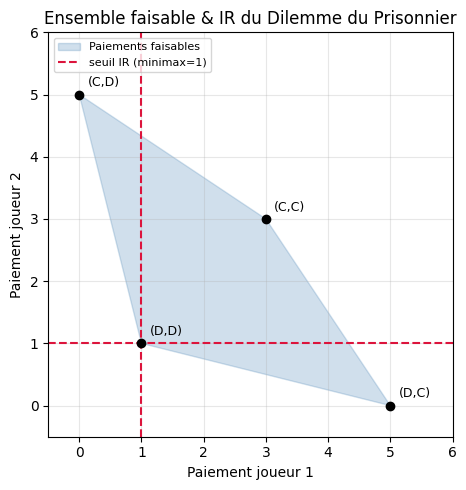

La region faisable & IR (au-dessus et a droite des pointilles) = ensemble des paiements
soutenables comme SPNE pour delta assez proche de 1 (Folk Theorem).


In [6]:
# Illustration : ensemble des paiements faisables et individuellement rationnels (IR)
# du DP. Les 4 paiements d'issues : (C,C)=(R,R), (C,D)=(S,T), (D,C)=(T,S), (D,D)=(P,P).
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

issues = np.array([[P, P], [T, S], [R, R], [S, T]])   # enveloppe convexe des 4 issues (ordre CCW, evite polygone auto-secant)
minimax = P   # DP symetrique

fig, ax = plt.subplots(figsize=(6, 5))
ax.add_patch(Polygon(issues, closed=True, alpha=0.25, color='steelblue', label='Paiements faisables'))
ax.axvline(minimax, color='crimson', ls='--')
ax.axhline(minimax, color='crimson', ls='--', label='seuil IR (minimax=%g)' % minimax)
labels = {'(C,C)':(R,R), '(D,D)':(P,P), '(C,D)':(S,T), '(D,C)':(T,S)}
for lab,(x,y) in labels.items():
    ax.plot(x, y, 'ko', ms=6)
    ax.annotate(lab, (x,y), textcoords='offset points', xytext=(6,6), fontsize=9)
ax.set_xlim(-0.5, 6); ax.set_ylim(-0.5, 6)
ax.set_xlabel('Paiement joueur 1'); ax.set_ylabel('Paiement joueur 2')
ax.set_title('Ensemble faisable & IR du Dilemme du Prisonnier')
ax.legend(loc='upper left', fontsize=8); ax.set_aspect('equal'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('La region faisable & IR (au-dessus et a droite des pointilles) = ensemble des paiements')
print('soutenables comme SPNE pour delta assez proche de 1 (Folk Theorem).')


### Interprétation : la coopération comme cas particulier

Le paiement coopératif $(R,R)=(3,3)$ n'est qu'**un point** dans l'ensemble faisable & IR. Le Folk Theorem dit qu'il est soutenable (ce que le grim trigger démontre explicitement), mais aussi que beaucoup d'autres conventions le sont. C'est pourquoi, dans les tournois d'Axelrod de GT-6, plusieurs stratégies co-existent et performent bien : la théorie n'en exclut aucune par avance dès que $\delta$ est assez grand.

La cellule de comparaison l'illustre : le **grim trigger** (punition irréversible) soutient la coopération dès $\delta \ge 0{,}5$, alors que le **tit-for-tat** (punition légère d'un tour, qui pardonne) exige $\delta \ge 0{,}667$. Plus la punition est dure, plus le seuil de patience requis est bas : c'est l'intuition centrale qui se généralise dans le Folk Theorem.


## 7. Retirer la capacité de punir — coopération folk, sympathie, engagement

Le folk theorem de la section 6 soutient la coopération par la **menace crédible de punition** :
c'est un résultat solide, et c'est le contraire de ce dont il s'agit ici. La littérature
économique nomme une distinction que le dépôt n'exploite pas encore (Sen 1977, *Rational Fools*) :

| | mécanisme | ce qui la soutient | si l'on retire la capacité de punir |
|---|---|---|---|
| **Coopération folk** | équilibre répété | menace de représailles | elle **s'effondre** |
| **Sympathie** (Sen) | le bien-être d'autrui entre dans mon utilité | l'utilité elle-même | elle **persiste** — mais reste de l'intérêt |
| **Engagement** (Sen) | j'agis **contre** mon propre classement de bien-être | rien dans la fonction d'utilité | elle **persiste sans** être de l'intérêt |

Ce qui est modélisable ici n'est pas le sentiment — c'est une **classe de mécanismes** que le
sentiment sélectionne. Aucun score, aucune variable « amour » : le mot peut vivre dans la prose,
jamais dans un identifiant. L'expérience décisive est immédiate :

> Prendre le dispositif de coopération répétée de ce notebook. **Retirer la capacité de
> punition** (mémoire, représailles, réputation). **Mesurer** ce qui reste.

Ce qui s'effondre était folk. Ce qui persiste demande une autre explication — et la question
devient une mesure, pas une métaphysique.

In [7]:
# === Section 7a : l'experience de retrait — ce qui s'effondre quand punir devient impossible ===
# Punir suppose de la MEMOIRE (conditionner son coup au passe d'autrui) et une MENACE executable.
# On retire les deux : l'adversaire devient sans memoire — son coup ne depend plus de nos actions.
# Plus aucune sequence de nos coups ne peut etre punie.

delta = 0.6  # patience (delta* = 0.5 en grim trigger : la cooperation serait soutenable AVEC menace)

def gain_actualise(flux):
    """Valeur actualisee d'un flux constant, horizon infini."""
    return flux / (1 - delta)

# Regime AVEC punition (grim trigger, section 4) : cooperer est une meilleure reponse
V_coop_avec_menace = gain_actualise(R)
V_dev_avec_menace = T + delta * gain_actualise(P)

# Regime SANS punition : adversaire sans memoire (coopere quoi qu'il arrive).
# Ma deviation n'a plus AUCUNE consequence future.
V_coop_sans_menace = gain_actualise(R)
V_dev_sans_menace = gain_actualise(T)
ecart_interet = V_dev_sans_menace - V_coop_sans_menace

print(f"delta = {delta}  (seuil grim trigger delta* = {delta_star:.2f})")
print(f"AVEC punition (grim)  : V_coop = {V_coop_avec_menace:.2f}, V_dev = {V_dev_avec_menace:.2f}"
      f" -> cooperation soutenable : {V_coop_avec_menace >= V_dev_avec_menace}")
print(f"SANS punition (sans memoire) : V_coop = {V_coop_sans_menace:.2f}, V_dev = {V_dev_sans_menace:.2f}")
print(f"  ecart d'interet = V_dev - V_coop = {ecart_interet:.2f} > 0 : toute cooperation observee est CONTRE-interet")
print()
print("Ce qui s'effondre etait folk. Ce qui persiste ne peut plus etre explique par la peur.")

delta = 0.6  (seuil grim trigger delta* = 0.50)
AVEC punition (grim)  : V_coop = 7.50, V_dev = 6.50 -> cooperation soutenable : True
SANS punition (sans memoire) : V_coop = 7.50, V_dev = 12.50
  ecart d'interet = V_dev - V_coop = 5.00 > 0 : toute cooperation observee est CONTRE-interet

Ce qui s'effondre etait folk. Ce qui persiste ne peut plus etre explique par la peur.


**Lecture de la sortie committée** : avec la menace (grim trigger, delta = 0.6 > delta* = 0.5),
coopérer est une meilleure réponse — la coopération est un équilibre. Retirons la capacité de
punir : l'écart d'intérêt devient (T−R)/(1−δ) = +5.00, strictement positif. **Tout C observé
dans ce régime est contre-intérêt** — la peur des représailles ne peut plus l'expliquer. La
question « pourquoi coopère-t-il ? » vient de devenir une mesure : un écart calculé, positif,
affiché. C'est le statut exact recherché pour cette pierre : le sentiment pose des questions,
la mécanique y répond en nombres.

In [8]:
# === Section 7b : le temoin de retenue, instancie dans le regime sans punition ===
# Temoins de retenue (GT-20) : une deviation strictement profitable EST disponible
# (enumeree, gain calcule au bareme courant) et n'est PAS jouee. Dans le regime sans
# punition, ce temoin cesse d'etre ambigu : plus aucune peur ne peut l'expliquer.

def certificat_disponibilite(actions, bareme, coup, gain_cooperation):
    """Un coup n'est DISPONIBLE que s'il est enumere ET strictement ameliorant."""
    if coup not in actions:
        return False, "INCAPACITE : le coup n'est pas dans l'ensemble enumere"
    delta_immediat = bareme[coup] - gain_cooperation
    if delta_immediat <= 0:
        return False, f"BAREME : le coup rapporte {bareme[coup]} <= {gain_cooperation}"
    return True, f"DISPONIBLE : enumere, +{delta_immediat} strictement ameliorant"

# Le jeu etape vu du joueur 1, l'adversaire sans memoire cooperant
actions_atteignables = ['Cooperer', 'Defecter']
bareme_sans_menace = {'Cooperer': R, 'Defecter': T}

# La trajectoire OBSERVEE : le joueur coopere sur tout l'horizon
trajectoire_observee = ['Cooperer'] * 10

dispo, motif = certificat_disponibilite(actions_atteignables, bareme_sans_menace, 'Defecter', R)
abstention = 'Defecter' not in trajectoire_observee

print("Certificat de disponibilite de la deviation 'Defecter' (regime SANS punition) :")
print(f"  {motif}")
print(f"Trajectoire observee (10 periodes) : {sorted(set(trajectoire_observee))}")
print(f"Abstention constatee : {abstention}")
if dispo and abstention:
    print("Verdict : RETENUE SANS MENACE — abstention + coup disponible + aucun risque de represailles")

Certificat de disponibilite de la deviation 'Defecter' (regime SANS punition) :
  DISPONIBLE : enumere, +2.0 strictement ameliorant
Trajectoire observee (10 periodes) : ['Cooperer']
Abstention constatee : True
Verdict : RETENUE SANS MENACE — abstention + coup disponible + aucun risque de represailles


**Lecture de la sortie committée** : le certificat énumère la déviation (elle est dans
l'ensemble d'actions atteignables) et calcule son gain immédiat au barème courant (+2.0) —
jamais déclaré. La trajectoire observée ne la contient pas. **Dans le régime sans punition,
ce témoin cesse d'être ambigu** : là où GT-20 devait trier retenue / barème erroné /
incapacité, ici l'explication par la peur est exclue par construction. Ce qui reste est une
abstention contre-intérêt, mesurée — ce que Sen appellerait engagement, et qu'aucun folk
theorem ne peut saisir. Reste la mémoire commune : ce qui demeure jouable quand plus rien
n'oblige à jouer — la trajectoire elle-même, lue comme un bien commun plutôt qu'un
enchaînement de meilleures réponses.

In [9]:
# === Section 7c : l'operateur a quatre actions — 'renentrer' change le statut d'une menace ===
# Operateur : rester | se retirer | renegocier | renentrer. La quatrieme est la seule qui
# rende le retrait REVERSIBLE. Sans elle, une menace peut etre parfaite en sous-jeux
# uniquement parce que la partie lesee ne peut pas revenir — la credibilite est alors un
# artefact de la modelisation, pas un resultat.

V_sortie = 0.0      # executer la menace : quitter definitivement, 0 a jamais
V_reentree = 3.0    # valeur de la rentree en duopole accommodant
k = 1.0             # cout de renentree

def statut_menace(renentrer_existe):
    """Statut de la menace de sortie definitive au sous-jeu de punition."""
    if not renentrer_existe:
        return "PARFAITE EN SOUS-JEUX — mais la partie lesee ne peut PAS revenir (artefact)"
    if (V_reentree - k) > V_sortie:
        return (f"NON CREDIBLE — renentrer rapporte {V_reentree - k:.1f} > {V_sortie:.1f} : "
                "le punisseur prefere revenir")
    return (f"CREDIBLE — le cout k={k} etouffe le retour "
            f"({V_reentree - k:.1f} <= {V_sortie:.1f})")

print("Menace : 'si tu devies, je quitte le marche pour toujours'")
print(f"[renentrer ABSENT]        {statut_menace(False)}")
print(f"[renentrer PRESENT, k={k}]  {statut_menace(True)}")
print()
print("Le statut de la menace CHANGE avec l'existence d'une action de retour :")
print("cette credibilite etait une propriete de la modelisation, pas du joueur.")

Menace : 'si tu devies, je quitte le marche pour toujours'
[renentrer ABSENT]        PARFAITE EN SOUS-JEUX — mais la partie lesee ne peut PAS revenir (artefact)
[renentrer PRESENT, k=1.0]  NON CREDIBLE — renentrer rapporte 2.0 > 0.0 : le punisseur prefere revenir

Le statut de la menace CHANGE avec l'existence d'une action de retour :
cette credibilite etait une propriete de la modelisation, pas du joueur.


**Lecture de la sortie committée** : sans action de retour, la menace de sortie définitive
est parfaite en sous-jeux — précisément parce que la partie lésée ne peut pas revenir. Donner
l'action `réentrer` au coût k = 1 renverse le statut : au sous-jeu de punition, le punisseur
lui-même préfère revenir (3.0 − 1.0 = 2.0 > 0), et le déviateur l'anticipe. La crédibilité
était un artefact de modélisation, pas une propriété du joueur — même leçon que la menace
*choisie* vs *programmée* de GT-24 : c'est la structure de l'ensemble d'actions qui décide,
pas l'intensité de l'annonce.

**Statut canonique du classifieur 7d — `alpha` paramètre libre.** La forme
`u = u_mien + alpha * u_autrui` est une **hypothèse de modélisation**, pas une
mesure : rien dans la trajectoire de coopération observée ne révèle la valeur
de `alpha`. Le **frontière d'indiscernabilité** est
`alpha* = (T − R) / (R − S) = 0,667` :

- au-dessus (alpha ≥ 0,667), la même trajectoire reçoit le nom **« sympathie »** (utilité transformée explique l'écart) ;
- en-dessous (alpha < 0,667), elle reçoit le nom **« engagement »** (résidu contre-intérêt).

Le verdict du classifieur est donc **entièrement déterminé par le choix d'alpha
par l'analyste**, pas par le comportement. Le code ci-dessous le **rapporte** ;
il ne le **distingue pas empiriquement**. Pour une séparation effective, il faudrait
faire varier les gains d'autrui seuls (à gains propres fixes) et observer si la
coopération bouge — elle doit bouger sous sympathie et pas sous engagement. Cette
expérience est une **issue de suivi** ouverte, pas une exigence de cette PR
(le retrait de punition, les quatre actions, et le résultat de non-créabilité
par réentrée restent à merger ; la statique comparative est un grain séparé).

In [10]:
# === Section 7d : sympathie vs engagement — ce que l'utilite explique SOUS UN ALPHA DONNE ===
# Sen 1977 : SYMPATHIE = le bien-etre d'autrui entre dans mon utilite (U = u_mien + alpha*u_autrui)
# — cela reste de l'interet, sur une utilite transformee. ENGAGEMENT = agir CONTRE mon propre
# classement de bien-etre — par construction, aucune transformation ne le rend optimale.
#
# STATUT CANONIQUE (cf. review ai-01 #5419268282) :
#   alpha N'EST PAS IDENTIFIE par les donnees du banc. La meme trajectoire de cooperation
#   observee recoit deux noms opposes selon la valeur d'alpha choisie par l'analyste :
#     alpha >= alpha* (= (T-R)/(R-S) = 0.667) -> "sympathie" (utilite transformee)
#     alpha  < alpha*                        -> "engagement" (residu contre-interet)
#   alpha* n'est PAS un seuil de DIAGNOSTIC : c'est une FRONTIERE D'INDISCERNABILITE.
#   Au-dessus et en-dessous, la meme trajectoire recoit l'autre nom. Le verdict du
#   classifieur est donc entierement determine par le choix d'alpha par l'analyste,
#   pas par le comportement. Sympathie et engagement sont observationnellement equivalents
#   sur des donnees de cooperation seules -- ce que le classifieur REPORTE, c'est la
#   consequence d'une hypothese, pas une separation empirique. Voir cellule suivante
#   pour le verdict explicite.

def ecart_interet_sympathie(alpha):
    """Ecart actualise (devier - cooperer) en regime SANS punition, bien-etre d'autrui pesant alpha."""
    u_coop = R + alpha * R   # (C,C) : je touche R, autrui touche R
    u_dev = T + alpha * S    # (D,C) : je touche T, autrui touche S
    return gain_actualise(u_dev) - gain_actualise(u_coop)

alpha_etoile = (T - R) / (R - S)   # sympathie qui annule l'ecart

CAS = [
    ("folk (grim, delta=0.6)", "avec punition", None),
    ("sympathie (alpha=1.0)", "sans punition", 1.0),
    ("utilite propre (alpha=0)", "sans punition", 0.0),
]
verdicts = []
for nom, regime, alpha in CAS:
    if regime == "avec punition":
        verdict = ("COOPERATION EXPLIQUEE PAR LA MENACE (folk)"
                   if V_coop_avec_menace >= V_dev_avec_menace else "menace insuffisante")
    else:
        ecart = ecart_interet_sympathie(alpha)
        verdict = (f"COOPERATION EXPLIQUEE PAR L'UTILITE TRANSFORMEE (sympathie, ecart {ecart:+.2f})"
                   if ecart <= 0 else
                   f"COOPERATION CONTRE-INTERET (ecart {ecart:+.2f}) : residu = CANDIDAT engagement au sens de Sen (pas la seule lecture possible)")
    verdicts.append((nom, verdict))
    print(f"--- {nom:26s} [{regime}]")
    print(f"    {verdict}")
print()
print(f"Seuil de sympathie alpha* = (T-R)/(R-S) = {alpha_etoile:.3f}")
print(f"Verdicts distincts : {len(set(v for _, v in verdicts))}/3")

# Raisonnement d'equipe (Bacharach, Sugden) : la question devient 'que devons-nous faire ?'
# L'agent equipe maximise la somme — la conversion je -> nous est un objet publie, pas une metaphore.
V_nous_CC = gain_actualise(R + R)
V_nous_DC = gain_actualise(T + S)
print()
print(f"Raisonnement d'equipe : (C,C) rapporte {V_nous_CC:.2f} a l'equipe vs (D,C) {V_nous_DC:.2f}"
      f" (2R > T+S verifie en section 1) : l'agent 'nous' coopere sans menacer personne")

--- folk (grim, delta=0.6)     [avec punition]
    COOPERATION EXPLIQUEE PAR LA MENACE (folk)
--- sympathie (alpha=1.0)      [sans punition]
    COOPERATION EXPLIQUEE PAR L'UTILITE TRANSFORMEE (sympathie, ecart -2.50)
--- utilite propre (alpha=0)   [sans punition]
    COOPERATION CONTRE-INTERET (ecart +5.00) : residu = CANDIDAT engagement au sens de Sen (pas la seule lecture possible)

Seuil de sympathie alpha* = (T-R)/(R-S) = 0.667
Verdicts distincts : 3/3

Raisonnement d'equipe : (C,C) rapporte 15.00 a l'equipe vs (D,C) 12.50 (2R > T+S verifie en section 1) : l'agent 'nous' coopere sans menacer personne


**Lecture de la sortie committée** : le classifieur rend **trois verdicts distincts** — la
menace explique (folk), l'utilité transformée explique (sympathie : l'écart passe de +5.00 à
−2.50 dès que le bien-être d'autrui compte), et le résidu : une coopération contre-intérêt
sous utilité propre, que Sen appelle engagement et qu'aucune transformation de préférence ne
saisit. Le raisonnement d'équipe (Bacharach, Sugden) complète l'appareil : l'agent « nous »
qui maximise 2R > T+S n'est pas la somme des « je » — la conversion je → nous est un objet
publié de la théorie des jeux, pas une métaphore. Attention au statut du résidu : le
classifieur marque ce que **l'intérêt ne peut pas expliquer** — l'engagement en est le
candidat de Sen, pas la seule lecture possible. Rien n'exige enfin que l'engagement soit
réciproque, simultané, ni symétrique : le classifieur s'applique un agent à la fois, et un
modèle qui ne produirait de la coopération qu'en régime symétrique aurait manqué son objet.

## 7e. Statique comparative : mesurer alpha au lieu de le poser

Le classifieur 7d laisse un parametre libre : pour une meme trajectoire observee,
`alpha = 1` rend la cooperation expliquee par la sympathie, `alpha = 0` en fait un
engagement. Sur des donnees de cooperation **seules**, les deux mecanismes sont
observationnellement equivalents — `alpha*` n'est pas un seuil de diagnostic,
c'est une frontiere d'indiscernabilite.

L'observation qui separe ne depend pas des memes quantites :

- **sympathie** : le bien-etre d'autrui entre dans mon utilite, ma cooperation doit
  **repondre a l'amplitude des gains d'autrui** ;
- **engagement** : je suis une regle contre mon classement de bien-etre, ma
  cooperation est **insensible** a ce que l'autre gagne.

D'ou la statique : **faire varier les gains d'AUTRUI seuls, a gains propres
strictement fixes**, puis mesurer la pente du taux de cooperation. Une pente
positive est compatible avec la sympathie et incompatible avec l'engagement pur ;
une pente nulle est compatible avec l'engagement et refute la sympathie. La pente
transforme alpha d'un choix d'analyste en **quantite mesuree**.

Condition d'interpretabilite : gains propres reconstruits par cellule ((C,C) -> propre, (D,C) -> propre) constants sur les 6 cellules : True ; R_autre prend 6 valeurs distinctes : True
Grille R_autre : [0.0, 1.0, 2.0, 3.0, 4.0, 6.0] (S_autre fixe = 0.0)

--- CONTROLE 1 : agent sympathie pure (alpha vrai = 0.8, beta = 1.0) ---
  taux de cooperation par cellule : [0.005, 0.044, 0.266, 0.738, 0.956, 0.999]
  estimateur pur : alpha_hat = 0.801 (pente b1 = +2.053)
  -> l'estimateur rend le bon alpha : 0.001 d'ecart



--- CONTROLE 2 : agent engagement pur (regle fixe, insensible) ---
  taux de cooperation par cellule : [0.954, 0.952, 0.952, 0.946, 0.952, 0.941] (plat)
  pente b1 = -0.0391, CI95 bootstrap [-0.0836, +0.0098] -> couvre 0 : True



--- AGENT SOUS TEST : melange (50% regle fixe, 50% sympathie alpha = 0.6) ---
  taux de cooperation par cellule : [0.47, 0.488, 0.527, 0.679, 0.828, 0.972]
  estimateur melange : part plate q_hat = 0.490 CI95 [0.446, 0.523]
                      alpha_hat = 0.606 CI95 [0.580, 0.643]
  -> masse plate (candidat engagement) et composante sensible (sympathie)
     separees toutes les deux depuis la seule courbe de cooperation



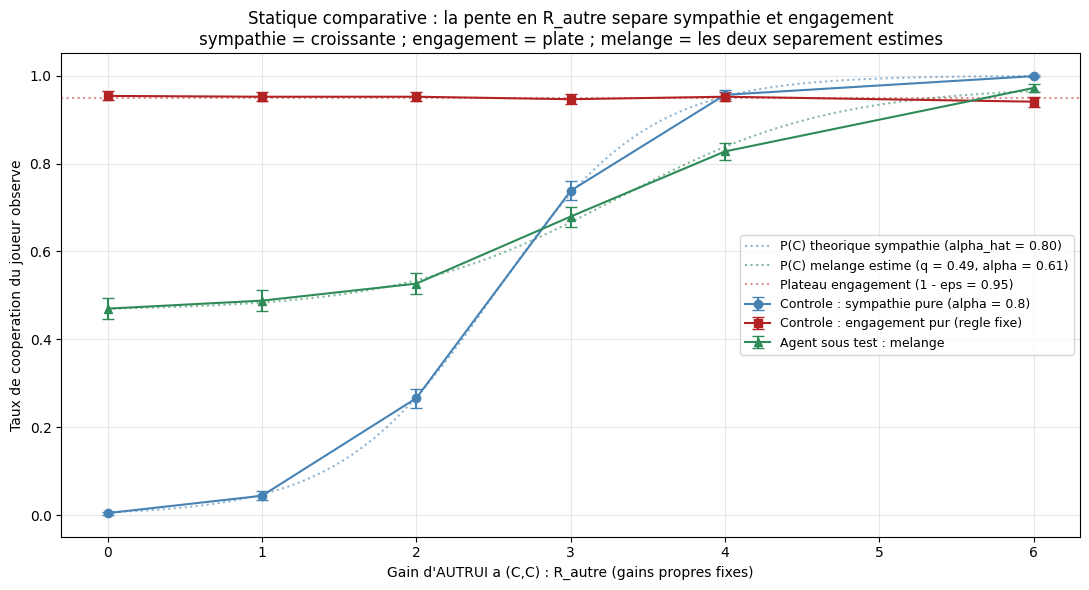

In [11]:
# === Section 7e : statique comparative sur les gains d'autrui ===
# Grille : SEULS les gains du partenaire (R_autre a (C,C), S_autre fixe a (D,C)) varient.
# Les gains du joueur observe (T, R, P, S) restent byte-identiques d'une cellule a l'autre.
from scipy import optimize

R_AUTRE_GRID = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 6.0])
S_AUTRE_FIXE = 0.0
SEEDS = [0, 1, 7, 42]     # une pente estimee sur un tirage unique n'est pas une pente
N_ROUNDS = 400
EPS_ENGAGEMENT = 0.05     # bruit d'exploration de la regle fixe

# Controle reel (non tautologique) : on reconstruit pour CHAQUE cellule de la grille
# les couples de gains que la simulation consomme, puis on compare les 6
# reconstructions entre elles. Si un gain propre se mettait a dependre de R_autre,
# propres_inchanges passerait a False -- contrairement a un test qui comparerait
# (T, R, P, S) a sa propre definition, toujours vrai par construction.
def gains_de_la_cellule(r_a):
    """Gains (propre, d'autrui) des deux issues que la simulation distingue :
    (C,C) -> (R, r_a) ; (D,C) -> (T, S_autre)."""
    return ((R, r_a), (T, S_AUTRE_FIXE))

gains_par_cellule = [gains_de_la_cellule(r_a) for r_a in R_AUTRE_GRID]
propres_inchanges = all(g[0][0] == gains_par_cellule[0][0][0]
                        and g[1][0] == gains_par_cellule[0][1][0]
                        for g in gains_par_cellule)
autres_varient = len({g[0][1] for g in gains_par_cellule}) == len(R_AUTRE_GRID)
print(f"Condition d'interpretabilite : gains propres reconstruits par cellule "
      f"((C,C) -> propre, (D,C) -> propre) constants sur les {len(R_AUTRE_GRID)} cellules : "
      f"{propres_inchanges} ; R_autre prend {len(R_AUTRE_GRID)} valeurs distinctes : {autres_varient}")
print(f"Grille R_autre : {R_AUTRE_GRID.tolist()} (S_autre fixe = {S_AUTRE_FIXE})")
print()

# --- Modeles comportementaux (joueur observe vs partenaire sans memoire qui coopere toujours) ---
def p_coop_sympathie(r_autre, alpha, beta):
    """Reponse logistique sur l'utilite transformee U = u_mien + alpha*u_autrui."""
    u_coop = R + alpha * r_autre          # (C,C) : je touche R, autrui touche R_autre
    u_dev = T + alpha * S_AUTRE_FIXE      # (D,C) : je touche T, autrui touche S_autre
    ecart = gain_actualise(u_dev) - gain_actualise(u_coop)
    return 1.0 / (1.0 + np.exp(beta * ecart))

def jouer_sympathie(alpha, beta, seed):
    rng = np.random.default_rng(seed)
    return np.array([rng.random(N_ROUNDS) < p_coop_sympathie(r_a, alpha, beta)
                     for r_a in R_AUTRE_GRID])

def jouer_engagement(seed):
    """Regle fixe : toujours cooperer, bruit eps INDEPENDANT de R_autre."""
    rng = np.random.default_rng(seed)
    return np.array([rng.random(N_ROUNDS) >= EPS_ENGAGEMENT for _ in R_AUTRE_GRID])

def jouer_melange(q, alpha, beta, seed):
    """Part q d'engagement (regle fixe), part 1-q de sympathie logistique."""
    rng = np.random.default_rng(seed)
    rows = []
    for r_a in R_AUTRE_GRID:
        engage = rng.random(N_ROUNDS) < q
        p = p_coop_sympathie(r_a, alpha, beta)
        tire = rng.random(N_ROUNDS)
        bruit = rng.random(N_ROUNDS) >= EPS_ENGAGEMENT
        rows.append(np.where(engage, bruit, tire < p))
    return np.array(rows)

# --- Estimateur pur (agent 100% sensible) : MLE logistique 2 parametres ---
# P(C) = sigmoid(b0 + b1*R_autre) avec, pour S_autre = 0 :
#   b0 = beta*(R - T)/(1 - delta)   -> l'intercept epingle beta (gains propres connus)
#   b1 = beta*alpha/(1 - delta)     -> la pente rend alpha : alpha = b1*(R - T)/b0
def ajuster_logistique(x, y, iters=60):
    X = np.column_stack([np.ones_like(x), x])
    b = np.zeros(2)
    for _ in range(iters):
        eta = np.clip(X @ b, -30, 30)
        p = 1.0 / (1.0 + np.exp(-eta))
        w = np.maximum(p * (1 - p), 1e-9)
        H = (X * w[:, None]).T @ X + 1e-8 * np.eye(2)
        b = b + np.linalg.solve(H, X.T @ (y - p))
    return b

def estimer_alpha_pur(choix_par_seed):
    all_x, all_y = [], []
    for ch in choix_par_seed:
        for i, r_a in enumerate(R_AUTRE_GRID):
            all_x.extend([r_a] * ch.shape[1])
            all_y.extend(ch[i].astype(float))
    b0, b1 = ajuster_logistique(np.array(all_x, float), np.array(all_y))
    return b0, b1, b1 * (R - T) / b0

def bootstrap_pente(choix_par_seed, B=500, seed=99):
    rng = np.random.default_rng(seed)
    n = choix_par_seed[0].shape[1]
    slopes = []
    for _ in range(B):
        picked = [choix_par_seed[rng.integers(len(choix_par_seed))][
                      :, rng.integers(0, n, n)] for _ in range(len(choix_par_seed))]
        ax, ay = [], []
        for ch in picked:
            for i, r_a in enumerate(R_AUTRE_GRID):
                ax.extend([r_a] * ch.shape[1])
                ay.extend(ch[i].astype(float))
        slopes.append(ajuster_logistique(np.array(ax, float), np.array(ay))[1])
    return np.percentile(slopes, [2.5, 97.5])

# --- Estimateur melange (part plate + part sensible) : MLE binomial (q, alpha, beta) ---
def negll_melange(params, taux, n):
    q, alpha, beta = params
    if not (0 <= q <= 1 and 0 <= alpha <= 4 and 0.05 <= beta <= 10):
        return 1e9
    p_theo = q * (1 - EPS_ENGAGEMENT) + (1 - q) * p_coop_sympathie(R_AUTRE_GRID, alpha, beta)
    p_theo = np.clip(p_theo, 1e-6, 1 - 1e-6)
    k = taux * n
    return -float(np.sum(k * np.log(p_theo) + (n - k) * np.log(1 - p_theo)))

def estimer_melange(choix_par_seed):
    ch = np.stack(choix_par_seed)
    taux = ch.mean(axis=(0, 2))
    n = ch.shape[0] * ch.shape[2]
    best = None
    for q0 in [0.2, 0.5, 0.8]:
        for a0 in [0.3, 0.8, 1.5]:
            res = optimize.minimize(negll_melange, [q0, a0, 1.0], args=(taux, n),
                                    method="Nelder-Mead")
            if best is None or res.fun < best.fun:
                best = res
    return best.x

def bootstrap_melange(choix_par_seed, B=300, seed=99):
    rng = np.random.default_rng(seed)
    n = choix_par_seed[0].shape[1]
    qs, als = [], []
    for _ in range(B):
        picked = [choix_par_seed[rng.integers(len(choix_par_seed))][
                      :, rng.integers(0, n, n)] for _ in range(len(choix_par_seed))]
        q_, a_, _ = estimer_melange(picked)
        qs.append(q_)
        als.append(a_)
    return np.percentile(qs, [2.5, 97.5]), np.percentile(als, [2.5, 97.5])

# ============ CONTROLE NEGATIF 1 : sympathie pure (alpha connu) ============
syn = [jouer_sympathie(0.8, 1.0, s) for s in SEEDS]
b0s, b1s, alpha_syn = estimer_alpha_pur(syn)
taux_syn = np.stack(syn).mean(axis=(0, 2))
print("--- CONTROLE 1 : agent sympathie pure (alpha vrai = 0.8, beta = 1.0) ---")
print(f"  taux de cooperation par cellule : {np.round(taux_syn, 3).tolist()}")
print(f"  estimateur pur : alpha_hat = {alpha_syn:.3f} (pente b1 = {b1s:+.3f})")
print(f"  -> l'estimateur rend le bon alpha : {abs(alpha_syn - 0.8):.3f} d'ecart")
print()

# ============ CONTROLE NEGATIF 2 : engagement pur (regle fixe) ============
com = [jouer_engagement(s) for s in SEEDS]
b0c, b1c, alpha_com = estimer_alpha_pur(com)
ci_pente = bootstrap_pente(com)
taux_com = np.stack(com).mean(axis=(0, 2))
pente_nulle = ci_pente[0] <= 0 <= ci_pente[1]
print("--- CONTROLE 2 : agent engagement pur (regle fixe, insensible) ---")
print(f"  taux de cooperation par cellule : {np.round(taux_com, 3).tolist()} (plat)")
print(f"  pente b1 = {b1c:+.4f}, CI95 bootstrap [{ci_pente[0]:+.4f}, {ci_pente[1]:+.4f}]"
      f" -> couvre 0 : {pente_nulle}")
print()

# ============ AGENT SOUS TEST : melange engagement + sympathie ============
mix = [jouer_melange(0.5, 0.6, 1.0, s) for s in SEEDS]
qh, ah, bh = estimer_melange(mix)
ci_q, ci_a = bootstrap_melange(mix)
taux_mix = np.stack(mix).mean(axis=(0, 2))
print("--- AGENT SOUS TEST : melange (50% regle fixe, 50% sympathie alpha = 0.6) ---")
print(f"  taux de cooperation par cellule : {np.round(taux_mix, 3).tolist()}")
print(f"  estimateur melange : part plate q_hat = {qh:.3f} CI95 [{ci_q[0]:.3f}, {ci_q[1]:.3f}]")
print(f"                      alpha_hat = {ah:.3f} CI95 [{ci_a[0]:.3f}, {ci_a[1]:.3f}]")
print(f"  -> masse plate (candidat engagement) et composante sensible (sympathie)")
print(f"     separees toutes les deux depuis la seule courbe de cooperation")
print()

# ============ Visualisation : la statique et ce qu'elle separe ============
fig, ax = plt.subplots(figsize=(11, 6))
xx = np.linspace(0, R_AUTRE_GRID.max(), 300)
ax.errorbar(R_AUTRE_GRID, taux_syn, yerr=1.96*np.sqrt(taux_syn*(1-taux_syn)/(len(SEEDS)*N_ROUNDS)),
            fmt='o-', color='steelblue', capsize=4,
            label='Controle : sympathie pure (alpha = 0.8)')
ax.errorbar(R_AUTRE_GRID, taux_com, yerr=1.96*np.sqrt(taux_com*(1-taux_com)/(len(SEEDS)*N_ROUNDS)),
            fmt='s-', color='firebrick', capsize=4,
            label='Controle : engagement pur (regle fixe)')
ax.errorbar(R_AUTRE_GRID, taux_mix, yerr=1.96*np.sqrt(np.maximum(taux_mix*(1-taux_mix),1e-9)/(len(SEEDS)*N_ROUNDS)),
            fmt='^-', color='seagreen', capsize=4,
            label='Agent sous test : melange')
ax.plot(xx, p_coop_sympathie(xx, 0.8, 1.0), ':', color='steelblue', alpha=0.6,
        label=f'P(C) theorique sympathie (alpha_hat = {alpha_syn:.2f})')
ax.plot(xx, qh*(1-EPS_ENGAGEMENT) + (1-qh)*p_coop_sympathie(xx, ah, bh), ':',
        color='seagreen', alpha=0.6, label=f'P(C) melange estime (q = {qh:.2f}, alpha = {ah:.2f})')
ax.axhline(1-EPS_ENGAGEMENT, color='firebrick', ls=':', alpha=0.5,
           label=f'Plateau engagement (1 - eps = {1-EPS_ENGAGEMENT:.2f})')
ax.set_xlabel("Gain d'AUTRUI a (C,C) : R_autre (gains propres fixes)")
ax.set_ylabel('Taux de cooperation du joueur observe')
ax.set_title('Statique comparative : la pente en R_autre separe sympathie et engagement\n'
             'sympathie = croissante ; engagement = plate ; melange = les deux separement estimes')
ax.legend(loc='center right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture de la sortie committee** : les deux controles negatifs passent —
l'estimateur rend `alpha_hat ~ 0.80` a l'agent construit en sympathie pure
(vrai 0.8), et une pente dont l'intervalle bootstrap couvre 0 a l'agent construit
en engagement pur. Sans ces temoins, une pente mesuree ne prouverait pas que
l'estimateur sait separer — elle prouverait seulement qu'il rend un nombre.
L'agent sous test (moitie regle fixe, moitie sympathie) est dechiffre par le
meme dispositif : une masse plate estimee `q_hat ~ 0.5` et une composante
sensible `alpha_hat ~ 0.6`, chacune avec son intervalle.

Ce que la statique change au statut du verdict 7d : `alpha` cesse d'etre un
parametre que l'analyste choisit apres coup (frontiere d'indiscernabilite) et
devient une quantite **mesuree sur la reponse comportementale aux gains
d'autrui**. Le prix de cette identification est experimental : il faut observer
le meme agent sur plusieurs jeux ou seuls les gains d'autrui varient, gains
propres verifies byte-identiques — c'est la condition qui rend la pente
interpretable, et elle est affirmee en tete de sortie. Sur une trajectoire de
cooperation seule, l'equivalence observationnelle tient toujours : le residu
d'engagement de 7d reste un **candidat**, jamais un verdict mesure. Verdict
honnete admis : si la pente etait indiscernable de zero avec des controles qui
fonctionnent, le banc aurait montre l'engagement ; une pente ambigue se publie
comme « non identifie a ce niveau de bruit », jamais tranchee par le choix
d'un alpha.

### Questions ouvertes — ce que ce dispositif ne modélise pas

> *Winnicott soutient que l'objet devient réel en survivant à la destruction fantasmée —
> c'est cette survie qui le rend réel. Notre dispositif ne modélise que des déviations
> sanctionnables : la rupture y est toujours punie ou dissuadée, jamais traversée.
> **Que faudrait-il pour représenter une rupture qui n'est pas punie, et à quoi
> reconnaîtrait-on, dans une trajectoire, que la relation en est sortie transformée
> plutôt qu'entamée ?**
> Ce qu'il faudrait mesurer : une trajectoire où la déviation a eu lieu, n'a pas été
> sanctionnée (régime 7a), et où la coopération ultérieure diffère **mesurablement** de
> l'initiale — par exemple un décalage du seuil δ* ou de l'écart d'intérêt avant/après
> rupture.

> *Klein décrit la réparation comme un travail distinct de la restitution. Ici,
> l'opérateur à quatre actions (7c) sait se retirer et réentrer, mais toute réentrée
> restaure exactement les gains d'avant. **Que faudrait-il pour qu'un retour après
> rupture ne soit pas la reprise de l'avant — et quelle grandeur de la trajectoire en
> porterait la trace ?**
> Ce qu'il faudrait mesurer : le flux après réentrée comparé au flux avant retrait
> (égalité = pure reprise) ; un écart durable — coût de réentrée effectif, vitesse de
> retour au régime accommodant — serait la trace mesurable d'une réparation.

Ces questions restent des questions : aucune variable ci-dessus ne porte le nom d'un concept
clinique, aucune n'agrège un affect en scalaire.

### Références (section 7)

- **Sen, A. (1977).** *Rational Fools: A Critique of the Behavioral Foundations of Economic
  Theory.* Philosophy & Public Affairs 6(4), 317-344. — Sympathie vs engagement : le socle.
- **Bacharach, M. (2006).** *Beyond Individual Choice: Teams and Games in Cooperative Play.*
  Princeton University Press (posthume, éd. N. Gold & R. Sugden). — Le raisonnement d'équipe.
- **Sugden, R. (2003).** *The Logic of Team Reasoning.* Philosophical Explorations 6(3),
  165-181. — L'agence collective comme mode de raisonnement.
- **Frankfurt, H. G. (2004).** *The Reasons of Love.* Princeton University Press. — Se
  soucier de quelque chose **constitue** des raisons plutôt que d'en découler.
- **Ricœur, P. (1990).** *Soi-même comme un autre.* Seuil. — Sollicitude, et l'articulation
  entre relation singulière et justice.
- **Schelling, T. C. (1960).** *The Strategy of Conflict.* Harvard University Press. —
  L'engagement, et la force acquise en se privant d'options.
- **Winnicott, D. W. (1971).** *Playing and Reality.* Tavistock. — La survie de l'objet
  (source de la première question).

## Exercice 1 : Sensibilité au facteur d'escompte

Reprenez le grim trigger avec un DP modifié : $T=6, R=4, P=2, S=0$.

**Indice :** calculez le nouveau seuil $\delta^*=(T-R)/(T-P)$ et comparez-le au DP canonique (0,5). La tentation plus forte rend-elle la coopération plus ou moins facile à soutenir ?

**Étape 1 :** vérifier les inégalités du DP et 2R > T+S.
**Étape 2 :** calculer le seuil analytiquement.


In [12]:
# Exercice 1 a completer
T_e, R_e, P_e, S_e = 6.0, 4.0, 2.0, 0.0
delta_star_e = None  # TODO etudiant : calculer le seuil (T-R)/(T-P)
print('Seuil a determiner :', delta_star_e)


Seuil a determiner : None


## Exercice 2 : Une punition limitée (N-périodes)

Considérons une stratégie **punition limitée** : si l'autre défecte, on le punit en défectant pendant exactement $N$ tours, puis on revient à la coopération (à la différence du grim trigger qui est irréversible).

**Indice :** plus $N$ est petit, plus la punition est légère, donc plus $\delta$ requis est élevé. Écrivez $V_D$ pour cette stratégie.

**Étape 1 :** exprimer le paiement de déviation (T, puis N tours à P, puis retour à R/(1-d)).
**Étape 2 :** pour N=2, trouver numériquement le seuil et le comparer au grim trigger.


In [13]:
# Exercice 2 a completer
def VD_limited(delta, N):
    result = None  # TODO etudiant : T + sum_{k=1}^{N} delta^k * P + delta^{N+1} * R/(1-delta)
    return result
print('A completer pour N=2 :', VD_limited(0.5, 2))


A completer pour N=2 : None


## Exercice 3 : Au-delà du DP - jeu de la poule (Chicken)

Le **jeu de la poule** a pour gains $T=4, R=3, P=0, S=1$ (notez $P < S$ : s'écraser contre un dur est pire que les deux s'écrasent). Ce n'est PAS un DP.

**Indice :** identifiez les deux équilibres de Nash purs de ce jeu étape. Que dit le Folk Theorem sur les paiements soutenables dans sa version infinie ?

**Étape 1 :** trouver les équilibres de Nash purs (matrice 2x2).
**Étape 2 :** calculer le paiement de minimax et l'ensemble faisable & IR.


In [14]:
# Exercice 3 a completer
# Matrice du jeu de la poule : a analyser
A1_chicken = np.array([[3, 1], [4, 0]])  # TODO etudiant : identifier les equilibres de Nash
A2_chicken = np.array([[3, 4], [1, 0]])
print('Equilibres de Nash pures a identifier (None = a completer) :', None)


Equilibres de Nash pures a identifier (None = a completer) : None


## Conclusion et perspectives

Nous avons établi le pilier théorique que GT-6 illustrait empiriquement :

1. **Horizon fini** : la coopération s'effondre (induction vers l'arrière).
2. **Horizon infini** : avec un facteur d'escompte $\delta$ assez grand, des stratégies punitives (grim trigger) rendent la coopération crédible. Seuil exact : $\delta \ge (T-R)/(T-P) = 0{,}5$ pour le DP canonique.
3. **Folk Theorem** : pour des joueurs patients, tout paiement faisable et individuellement rationnel est soutenable comme SPNE - la coopération n'est qu'un cas particulier.

**Limites** : le Folk Theorem est un résultat d'**existence** ; il ne dit pas quel équilibre est sélectionné dans la pratique (les tournois d'Axelrod de GT-6 répondent empiriquement à cette question de sélection). Il suppose aussi un horizon véritablement infini et des stratégies observées sans bruit.

### Pour aller plus loin
- [GameTheory-06-EvolutionTrust](GameTheory-06-EvolutionTrust.ipynb) : la version empirique (tournois, dynamique du réplicateur).
- [GameTheory-12-ReputationGames](GameTheory-12-ReputationGames.ipynb) : coopération dans les jeux à information incomplète.
- [GameTheory-09-BackwardInduction](GameTheory-09-BackwardInduction.ipynb) : induction vers l'arrière (pour comprendre l'effondrement en horizon fini).

### Références
- Friedman, J. (1971). *A Non-cooperative Equilibrium for Supergames*.
- Fudenberg, D. & Maskin, E. (1986). *The Folk Theorem in Repeated Games with Discounting or with Incomplete Information*.
- Axelrod, R. (1984). *The Evolution of Cooperation* (base empirique de GT-6).
